# Импорты, seed и устройство

In [1]:
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Данные и первичный анализ

In [2]:
dataset = load_dataset("emotion")
dataset

for split in dataset:
    print(split, len(dataset[split]))

for i in range(5):
    print(dataset["train"][i])

labels = dataset["train"].features["label"].names
labels

train 16000
validation 2000
test 2000
{'text': 'i didnt feel humiliated', 'label': 0}
{'text': 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'label': 0}
{'text': 'im grabbing a minute to post i feel greedy wrong', 'label': 3}
{'text': 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'label': 2}
{'text': 'i am feeling grouchy', 'label': 3}


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Классифицируется эмоциональная окраска текста (6 классов: sadness, joy, love, anger, fear, surprise).

Датасет содержит короткие тексты и относительно сбалансирован по классам.  
Задача заключается в определении эмоции, выраженной в тексте, что может быть нетривиально из-за контекста и неоднозначности формулировок.

# Токенизация

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_texts = [dataset["train"][i]["text"] for i in range(3)]

encodings = tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=128
)

encodings

for i, text in enumerate(sample_texts):
    print("TEXT:", text)
    print("TOKENS:", tokenizer.convert_ids_to_tokens(encodings["input_ids"][i]))
    print("INPUT_IDS:", encodings["input_ids"][i])
    print("ATTENTION:", encodings["attention_mask"][i])
    print("-" * 50)

# Инференс готовой pretrained модели

In [3]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(labels)
)

def predict(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=1)
    
    return preds.numpy(), probs.detach().numpy()

sample_texts = [dataset["train"][i]["text"] for i in range(3)]

test_texts = sample_texts

preds, probs = predict(test_texts)

for text, pred in zip(test_texts, preds):
    print(text)
    print("PRED:", labels[pred])
    print()



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


i didnt feel humiliated
PRED: anger

i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
PRED: anger

im grabbing a minute to post i feel greedy wrong
PRED: anger



Готовая модель без fine-tuning предсказывает плохо и склонна к смещению в один класс, так как не обучена на задаче классификации эмоций.

# Fine-tuning модели

In [4]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenized_datasets.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

# Модель

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(labels)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Метрики

In [6]:
def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    preds = np.argmax(logits, axis=1)
    
    return {
        "accuracy": accuracy_score(labels_true, preds),
        "f1_macro": f1_score(labels_true, preds, average="macro")
    }

# TrainingArguments

In [7]:
training_args = TrainingArguments(
    output_dir="./results",

    do_train=True,
    do_eval=True,

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=1,

    logging_steps=100,

    seed=SEED,
    report_to="none"
)

# Trainer

In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics
)

# Обучение модели

In [9]:
best_f1 = 0
best_model_state = None

num_epochs = 3

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        compute_metrics=compute_metrics
    )
    
    trainer.train()
    
    val_output = trainer.predict(tokenized_datasets["validation"])
    
    preds = np.argmax(val_output.predictions, axis=1)
    true = val_output.label_ids
    
    current_f1 = f1_score(true, preds, average="macro")
    
    print("Validation f1_macro:", current_f1)
    
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_model_state = {
            k: v.cpu().clone() for k, v in trainer.model.state_dict().items()
        }

print("\nBest validation f1_macro:", best_f1)

model.load_state_dict(best_model_state)


Epoch 1/3


D:\IAI_course\abrician_course\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
100,1.471519
200,1.032541
300,0.783064
400,0.577580
500,0.460411
600,0.375309
700,0.375967
800,0.296905
900,0.272023
1000,0.276351


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

D:\IAI_course\abrician_course\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation f1_macro: 0.9058489063080236

Best validation f1_macro: 0.9098421353784713


<All keys matched successfully>

Лучшая модель выбирается по метрике f1_macro на validation.
Для этого после каждой эпохи выполняется предсказание на validation с помощью trainer.predict(),
после чего метрика вычисляется вручную и выбирается лучший вариант.

# Оценка на test

In [10]:
preds_output = trainer.predict(tokenized_datasets["test"])

preds = np.argmax(preds_output.predictions, axis=1)
true = preds_output.label_ids

test_accuracy = accuracy_score(true, preds)
test_f1 = f1_score(true, preds, average="macro")

print("Test accuracy:", test_accuracy)
print("Test f1_macro:", test_f1)

D:\IAI_course\abrician_course\homeworks\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.925
Test f1_macro: 0.8808517555411187


# Матрица ошибок

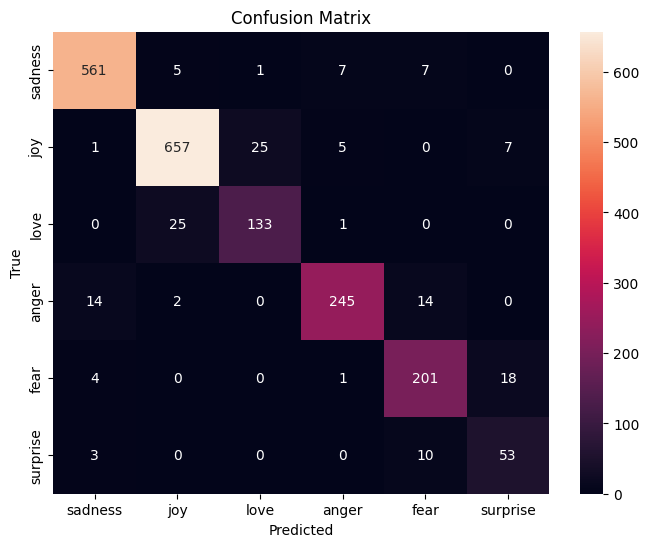

In [11]:
import os
os.makedirs("artifacts", exist_ok=True)

cm = confusion_matrix(true, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.savefig("artifacts/confusion_matrix.png")
plt.show()

# Примеры предсказаний

In [12]:
probs = torch.nn.functional.softmax(
    torch.tensor(preds_output.predictions), dim=1
).numpy()

confidences = probs.max(axis=1)

sample_df = pd.DataFrame({
    "text": [dataset["test"][i]["text"] for i in range(50)],
    "true_label": [labels[dataset["test"][i]["label"]] for i in range(50)],
    "pred_label": [labels[preds[i]] for i in range(50)],
    "confidence": confidences[:50]
})

sample_df.to_csv("artifacts/sample_predictions.csv", index=False)
sample_df.head()

,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.999774
1,im updating my blog because i feel shitty,sadness,sadness,0.999798
2,i never make her separate from me because i do...,sadness,sadness,0.999794
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.999630
4,i was feeling a little vain when i did this one,sadness,sadness,0.999796
